Visiting verl_grpo_chart2code_mllm_20251201_160707.log
the last metric collected is at: 2025-12-03 09:30 - Step 564
total metric(s) gathered: 564



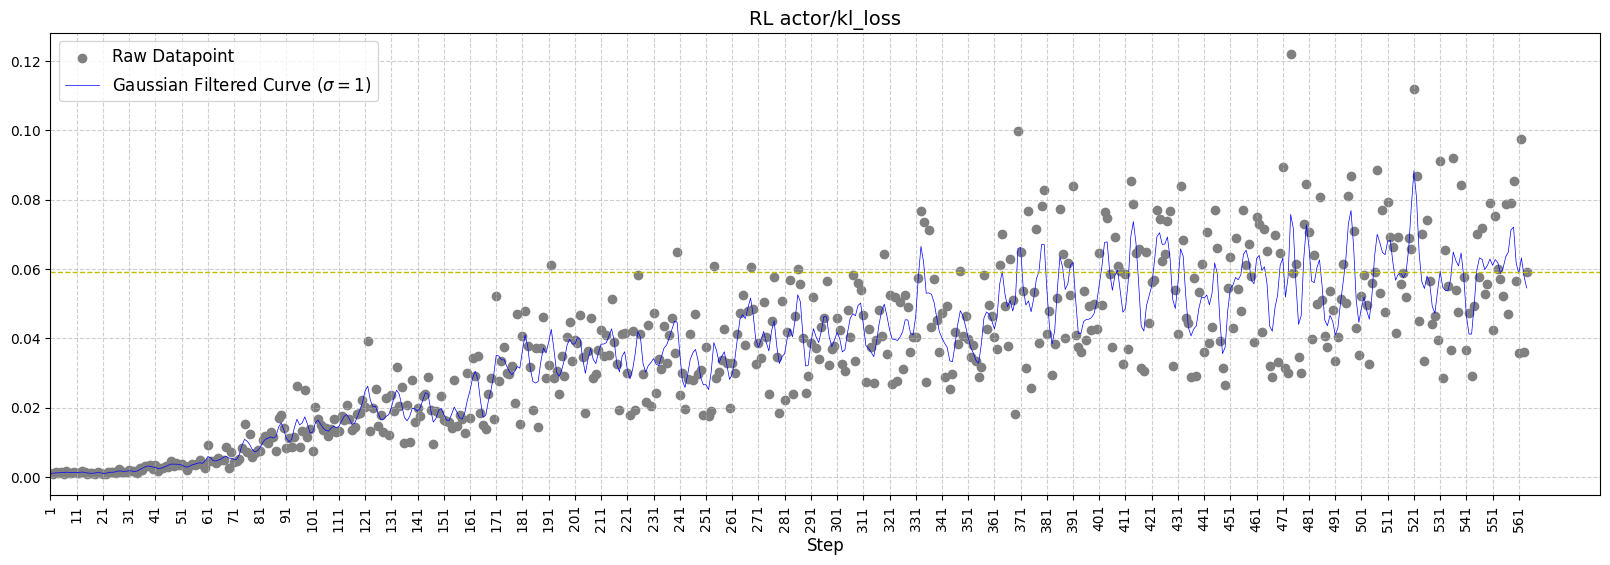

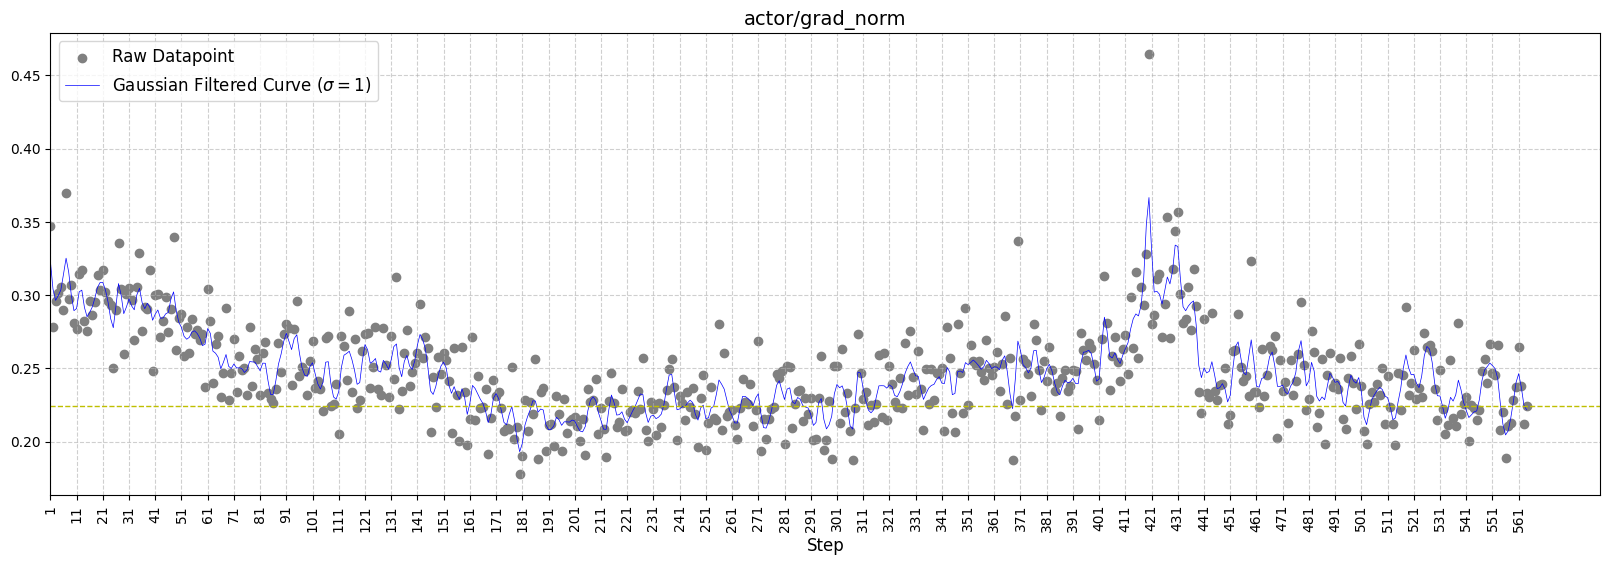

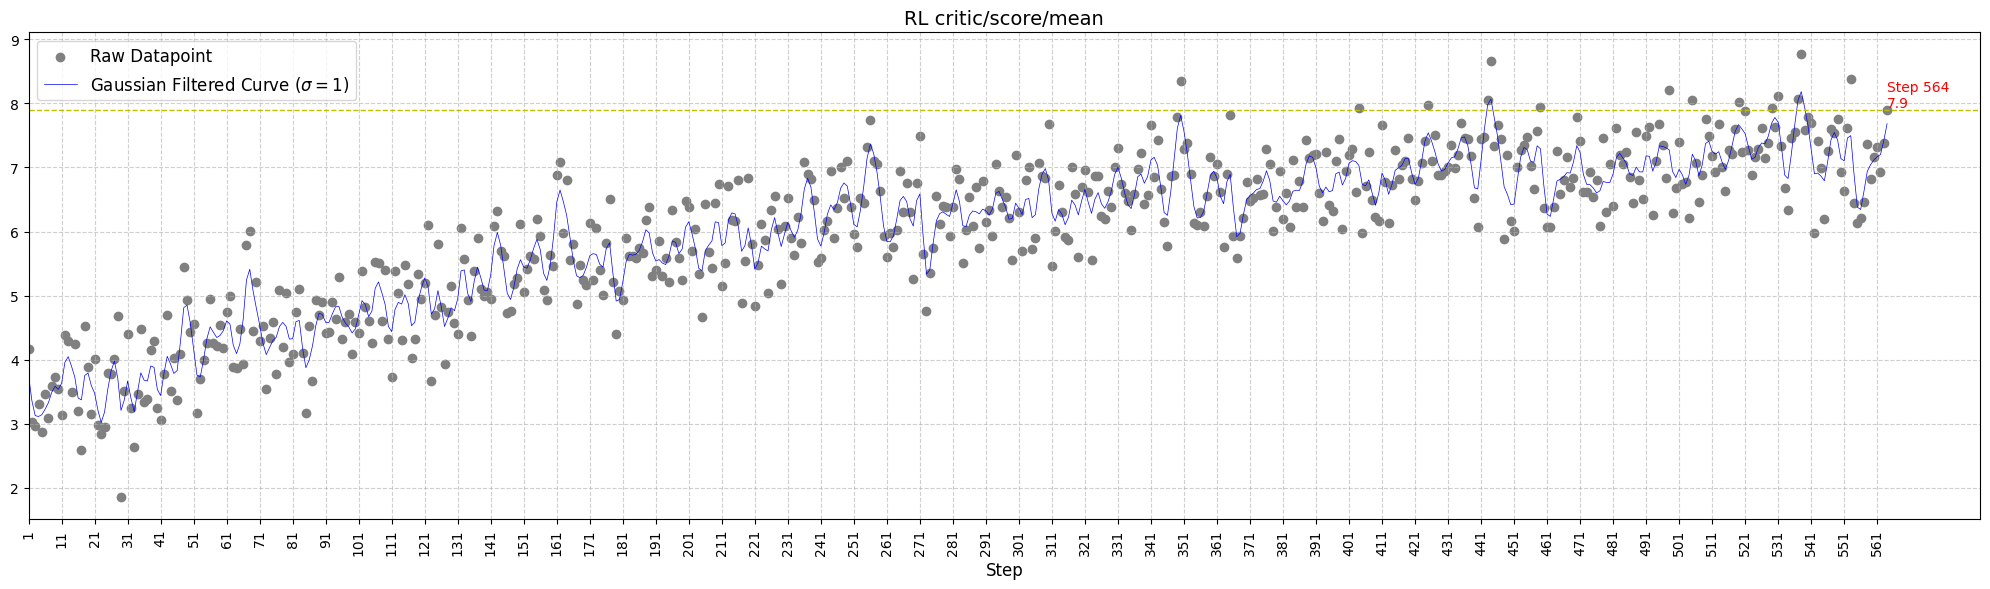

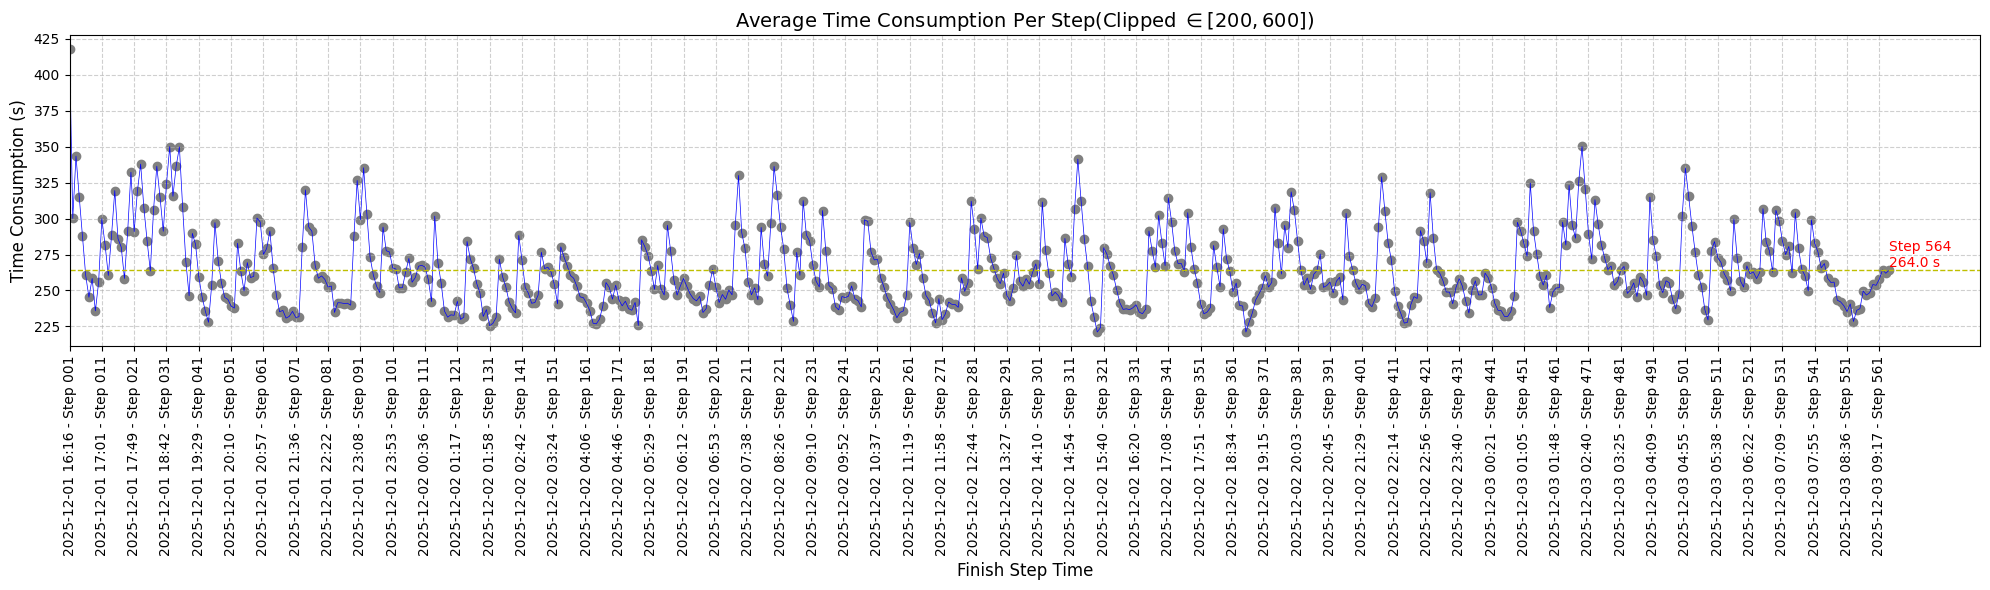

In [5]:
import collections
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import os
import re
import json
import time
from datetime import datetime, timedelta

is_time_consumption_clipped = True
clip_lower_bound = 200
clip_upper_bound = 600

gaussian_filter1d_sigma = 1
global_step_size = 10

score_dict = dict()
kl_loss_dict = dict()
grad_norm_dict = dict()
train_time_dict = collections.defaultdict(lambda: [0, 0])
score_distribution_set = set()

for filename in sorted(list(os.listdir('.'))):
    if not filename.startswith('verl_grpo_chart2code_mllm_') or not filename.endswith('.log'):
        continue

    print('Visiting', filename)

    with open(filename, 'r', encoding='utf-8') as f:
        # print('visiting', filename)
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                if 'Final Reward: {' in line:
                    line = line.split('Final Reward:')[1].strip()
                    row_dict = json.loads(line)
                    score_distribution_set.add(round(row_dict["score"], 1))
                if 'fit - [BATCH] metrics collected in global step ' in line:
                    line = line.split('fit - [BATCH] metrics collected in global step ')[1].strip()
                    step, metric_dict_str = line.split(": ", 1)
                    metric_dict = json.loads(metric_dict_str.strip())
                    score_dict[int(step)] = metric_dict["critic/score/mean"]
                    kl_loss_dict[int(step)] = metric_dict["actor/kl_loss"]
                    grad_norm_dict[int(step)] = metric_dict["actor/grad_norm"]
                if 'fit - END global step' in line:
                    step = int(line.rsplit('global step ')[1].split('/')[0])
                    time_pt = line.rsplit(' WARNING')[0].rsplit('[MainProcess:MainThread] ')[1].rsplit(':', 1)[0]
                    train_time_dict[step][0] = time_pt
                if 'Training Progress:' in line:
                    step = int(line.split("|", 2)[-1].split("/", 1)[0].strip())
                    match = re.search(r',\s*(.*?)\s*s/it', line)
                    if match:
                        result = match.group(1)
                        train_time_dict[step][1] = float(result)
            except Exception as e:
                import logging
                logging.error(e, exc_info=True)
                continue

x = [i for i in range(1, len(score_dict) + 1)]
x = np.asarray(x)
nums = [score_dict[idx] for idx in x]


kl_loss_nums = [kl_loss_dict[idx] for idx in x]
curve = gaussian_filter1d(kl_loss_nums, sigma=gaussian_filter1d_sigma)  # sigma 控制平滑程度

plt.figure(figsize=(20, 6))
plt.scatter(x, kl_loss_nums, color='gray', label='Raw Datapoint')
plt.plot(x, curve, 'b-', label=rf'Gaussian Filtered Curve ($\sigma={gaussian_filter1d_sigma}$)', linewidth=0.5)
plt.title('RL actor/kl_loss', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
last_value = kl_loss_nums[-1]
plt.axhline(y=last_value, color='y', linestyle='--', linewidth=1)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(x[::global_step_size], rotation=90)
plt.xlim(left=1)


grad_norm_nums = [grad_norm_dict[idx] for idx in x]
curve = gaussian_filter1d(grad_norm_nums, sigma=gaussian_filter1d_sigma)  # sigma 控制平滑程度

plt.figure(figsize=(20, 6))
plt.scatter(x, grad_norm_nums, color='gray', label='Raw Datapoint')
plt.plot(x, curve, 'b-', label=rf'Gaussian Filtered Curve ($\sigma={gaussian_filter1d_sigma}$)', linewidth=0.5)
plt.title("actor/grad_norm", fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
last_value = grad_norm_nums[-1]
plt.axhline(y=last_value, color='y', linestyle='--', linewidth=1)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(x[::global_step_size], rotation=90)
# plt.ylim(0.15, 0.25)
plt.xlim(left=1)


time_seq = [f'{train_time_dict[idx][0]} - Step {idx:03}' for idx in x]
train_times = [train_time_dict[idx][1] for idx in x]

if is_time_consumption_clipped:
    train_times = np.clip(train_times, clip_lower_bound, clip_upper_bound)

print(f'the last metric collected is at:', time_seq[-1])
print(f'total metric(s) gathered:', len(score_dict), end='\n\n')

nums = np.asarray(nums)

curve = gaussian_filter1d(nums, sigma=gaussian_filter1d_sigma)  # sigma 控制平滑程度

plt.figure(figsize=(20, 6))
plt.scatter(x, nums, color='gray', label='Raw Datapoint')
plt.plot(x, curve, 'b-', label=rf'Gaussian Filtered Curve ($\sigma={gaussian_filter1d_sigma}$)', linewidth=0.5)
plt.title('RL critic/score/mean', fontsize=14)
plt.xlabel('Step', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(x[::global_step_size], rotation=90)

last_value = nums[-1]
plt.axhline(y=last_value, color='y', linestyle='--', linewidth=1)
plt.text(x[-1], last_value, f'Step {x[-1]}\n{last_value:.1f}', 
         verticalalignment='bottom', horizontalalignment='left',
         color='red', fontsize=10)

plt.xlim(1)
# plt.ylim(6.5, 9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 6))
plt.scatter(time_seq, train_times, color='gray')
plt.plot(time_seq, train_times, 'b-', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title(f'Average Time Consumption Per Step(Clipped $\in [{clip_lower_bound}, {clip_upper_bound}]$)', fontsize=14)
plt.ylabel('Time Consumption (s)', fontsize=12)
plt.xlabel('Finish Step Time', fontsize=12)
plt.xticks(time_seq[::global_step_size], rotation=90)
plt.xlim(left=0)
# plt.ylim(600, 1500)


# 添加最后数据点的水平线和数值标记
last_value = train_times[-1]
plt.axhline(y=last_value, color='y', linestyle='--', linewidth=1)
plt.text(time_seq[-1], last_value, f'Step {time_seq[-1].split("- Step ")[-1]}\n{last_value:.1f} s', 
         verticalalignment='bottom', horizontalalignment='left',
         color='red', fontsize=10)

plt.tight_layout()
plt.show()
